# Evaluating Classification Models

## Learning Objectives

By the end of this notebook, you should be able to:

* Explain the purpose of classification metrics in evaluating predictive models
* Identify the components of a confusion matrix and interpret their meaning
* Calculate common classification metrics from a confusion matrix
* Compare different evaluation metrics and describe when each is appropriate
* Evaluate classification performance based on the cost of different prediction errors
* Apply classification metrics using functions from `sklearn.metrics`

---

In this notebook, we will explore how classification models are evaluated using metrics available in Python’s scikit-learn. Along the way, we will implement some of these metrics from scratch to connect their mathematical definitions with practical model evaluation.

One major area of predictive modeling in Data Science is **classification**. Classification aims to predict which class a particular observation belongs to.

For example, suppose we want to predict whether a patient will be re-hospitalized. In this case, there are two possible classes:

* **Hospitalized (positive)**
* **Not hospitalized (negative)**

<img src="../assets/classification.png" alt="Drawing" style="width: 400px;"/>

The illustration above shows a population of observations, each belonging to one of these classes. These observations are used to train a model that predicts whether a new observation should be classified as positive or negative.

Since models are rarely perfect, some observations will be classified incorrectly. This means that:

* some negative cases may be predicted as positive
* some positive cases may be predicted as negative

Understanding and measuring these prediction outcomes is an important part of evaluating classification models.

Once a classification model has been trained, the next step is to evaluate how well it performs.

There are many ways to measure classification performance, and each metric highlights a different aspect of model behavior. As a result, selecting the right metric depends on the problem you are trying to solve and the types of errors that matter most.

In Python, **scikit-learn** provides built-in tools for evaluating classification models.

The following sections introduce several commonly used evaluation metrics and demonstrate how to compute and interpret them using `sklearn.metrics`.

We will cover the following functions:

* `confusion_matrix`
* `accuracy_score`
* `recall_score`
* `precision_score`
* `f1_score`
* `roc_curve`
* `roc_auc_score`



## Loading the Data

Our sample dataset contains the **actual labels** (`actual_label`) and the **predicted probabilities** generated by two classification models (`model_RF` and `model_LR`).

The predicted probabilities represent each model’s estimated probability that an observation belongs to **class 1**.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    roc_auc_score,
)

In [4]:
df = pd.read_csv("../data/data.csv")
df.head()

,actual_label,model_RF,model_LR
0,1,0.639816,0.531904
1,0,0.490993,0.414496
2,1,0.623815,0.569883
3,1,0.506616,0.443674
4,0,0.418302,0.369532


In most Data Science projects, prediction probabilities are converted into predicted class labels using a **decision threshold**.

The choice of threshold depends on the **business context** and the relative cost of different types of prediction errors. For example, some problems may prioritize reducing false positives, while others may prioritize reducing false negatives.

For now, we will assume a threshold of **0.5**, meaning that:

* probabilities **greater than or equal to 0.5** are classified as **predicted positive**
* probabilities **below 0.5** are classified as **predicted negative**

Let's create two additional columns that convert the predicted probabilities into predicted class labels.


In [5]:
thresh = 0.5
df["predicted_RF"] = (df.model_RF >= thresh).astype("int")
df["predicted_LR"] = (df.model_LR >= thresh).astype("int")
df.head()

,actual_label,model_RF,model_LR,predicted_RF,predicted_LR
0,1,0.639816,0.531904,1,1
1,0,0.490993,0.414496,0,0
2,1,0.623815,0.569883,1,1
3,1,0.506616,0.443674,1,0
4,0,0.418302,0.369532,0,0


### Confusion Matrix

Given an **actual label** and a **predicted label**, each observation can be assigned to one of four categories:

* **True Positive (TP):** actual = 1, predicted = 1
* **False Positive (FP):** actual = 0, predicted = 1
* **False Negative (FN):** actual = 1, predicted = 0
* **True Negative (TN):** actual = 0, predicted = 0

These four categories form the foundation of the **confusion matrix**, a common tool used to evaluate classification models.


They can be visualised using the figure below ([adapted from original source](https://en.wikipedia.org/wiki/Precision_and_recall#/media/File:Precisionrecall.svg)). We will refer back to this diagram throughout the notebook when calculating and interpreting different classification metrics. 

<img src="../assets/buckets.png" alt="Drawing" style="width: 200px;"/>

The figure above illustrates the four possible prediction outcomes in a classification problem.

The rectangle represents the full population of observations and is divided vertically into two groups: **actual positives** (left) and **actual negatives** (right).

The circle represents all observations that were **predicted as positive**.

This creates four regions:

* The **left side inside the circle** represents **True Positives (TP)**: observations that are actually positive and predicted as positive.
* The **right side inside the circle** represents **False Positives (FP)**: observations that are actually negative but predicted as positive.
* The **left side outside the circle** represents **False Negatives (FN)**: observations that are actually positive but predicted as negative.
* The **right side outside the circle** represents **True Negatives (TN)**: observations that are actually negative and predicted as negative.

To simplify the discussion, we will refer to this visualization as the **rectangle–circle diagram**.


The same four categories can also be summarized in a confusion matrix, as shown below:

<img src="../assets/conf_matrix.png" alt="Drawing" style="width: 400px;"/>

The figure shows the so-called confusion matrix consisting of two rows and two columns:
- Rows refer to the actual classes
  - the upper row represents negative observations (actual = 0)
  - the lower row represents positive observations (actual = 1)
- Columns refer to the predictions. 
  - the left column represents negative predictions (predicted = 0)
  - the right column represents positive predictions (predicted = 1). 
  
The four matrix fields contain the number of predicted **true negatives**, **false positives**, **false negatives**, and **true positives** (upper left to lower right).

We can obtain the confusion matrix (as a 2x2 array) from scikit-learn, which takes as inputs the actual labels and the predicted labels

In [6]:
confusion_matrix(df.actual_label.values, df.predicted_RF.values)

array([[5519, 2360],
       [2832, 5047]])

The confusion matrix shows that there were **5,047 true positives**, **2,360 false positives**, **2,832 false negatives**, and **5,519 true negatives**.

Let's now implement our own functions from scratch to verify the results returned by `confusion_matrix`.

The first function has already been completed for you. Your task is to implement the remaining three functions.


In [7]:
def find_TP(y_true, y_pred):
    # counts the number of true positives (y_true = 1, y_pred = 1)
    return sum((y_true == 1) & (y_pred == 1))


def find_FN(y_true, y_pred):
    # counts the number of false negatives (y_true = 1, y_pred = 0)
    return sum((y_true == 1) & (y_pred == 0))


def find_FP(y_true, y_pred):
    # counts the number of false positives (y_true = 0, y_pred = 1)
    return sum((y_true == 0) & (y_pred == 1))


def find_TN(y_true, y_pred):
    # counts the number of true negatives (y_true = 0, y_pred = 0)
    return sum((y_true == 0) & (y_pred == 0))


print("TP:", find_TP(df.actual_label.values, df.predicted_RF.values))
print("FN:", find_FN(df.actual_label.values, df.predicted_RF.values))
print("FP:", find_FP(df.actual_label.values, df.predicted_RF.values))
print("TN:", find_TN(df.actual_label.values, df.predicted_RF.values))

TP: 5047
FN: 2832
FP: 2360
TN: 5519


Let's write a function that will calculate all four of these for us, and another function to duplicate `confusion_matrix`

In [8]:
def find_conf_matrix_values(y_true, y_pred):
    """calculate TP, FN, FP, TN"""
    TP = find_TP(y_true, y_pred)
    FN = find_FN(y_true, y_pred)
    FP = find_FP(y_true, y_pred)
    TN = find_TN(y_true, y_pred)
    return TP, FN, FP, TN


def my_confusion_matrix(y_true, y_pred):
    """display our own confusion matrix
    Returns a 2x2 numpy array with the following format:
    [[TN, FP],
     [FN, TP]]
     where:
     TN = True Negatives
     FP = False Positives
     FN = False Negatives
     TP = True Positives
    """
    TP, FN, FP, TN = find_conf_matrix_values(y_true, y_pred)
    return np.array([[TN, FP], [FN, TP]])

In [9]:
my_confusion_matrix(df.actual_label.values, df.predicted_RF.values)

array([[5519, 2360],
       [2832, 5047]])

Let's verify that our functions worked using Python's built in `assert` and NumPy's `array_equal` functions.

- The assert keyword is used when debugging code; it lets you test whether a condition in your code returns True. If not, the program will raise an AssertionError. [Source](https://www.w3schools.com/python/ref_keyword_assert.asp).
- `array_equal`: True if two arrays have the same shape and elements, False otherwise. [Source](https://numpy.org/doc/stable/reference/generated/numpy.array_equal.html)

In [10]:
try:
    assert np.array_equal(
        my_confusion_matrix(df.actual_label.values, df.predicted_RF.values),
        confusion_matrix(df.actual_label.values, df.predicted_RF.values),
    ), "my_confusion_matrix() is not correct for RF"

    assert np.array_equal(
        my_confusion_matrix(df.actual_label.values, df.predicted_LR.values),
        confusion_matrix(df.actual_label.values, df.predicted_LR.values),
    ), "my_confusion_matrix() is not correct for LR"

    print("my_confusion_matrix checks passed for RF and LR")
except AssertionError as e:
    print(f"Validation warning: {e}")
except Exception as e:
    print(f"Could not run confusion-matrix validation: {e}")

my_confusion_matrix checks passed for RF and LR


Given these four categories (TP, FP, FN, TN), we can calculate many other performance metrics.

### Accuracy Score

The most common metric for classification is accuracy, which is the fraction of samples predicted correctly as shown below: 

<img src="../assets/accuracy.png" alt="Drawing" style="width: 400px;"/>

The figure above illustrates the definition of **accuracy**, which measures the fraction of observations that were classified correctly.


Accuracy is calculated as:

* the number of **correct predictions** (**True Positives + True Negatives**)
  divided by
* the **total number of predictions** (**True Positives + True Negatives + False Positives + False Negatives**)

Using the rectangle–circle diagram:

* the **numerator** corresponds to the correctly classified observations (**True Positives and True Negatives**)
* the **denominator** corresponds to **all observations**

In other words, accuracy answers the question:

> *Of all the observations, how many did the model classify correctly?*


We can obtain the accuracy score from scikit-learn, which takes as inputs the actual labels and the predicted labels

In [11]:
accuracy_score(df.actual_label.values, df.predicted_RF.values)

0.6705165630156111

Define your own function that duplicates `accuracy_score`, using the formula above. 

In [12]:
def my_accuracy_score(y_true, y_pred):
    """own function for the metric accuracy"""
    # calculates the fraction of samples predicted correctly
    TP, FN, FP, TN = find_conf_matrix_values(y_true, y_pred)
    return (TP + TN) / (TP + FN + FP + TN)

**Explanation**

Accuracy is the share of all predictions that were correct, so we add the two correct buckets (TP and TN) and divide by the total number of observations. It reads easily but can mislead on imbalanced data, where always predicting the majority class already scores high.


In [13]:
try:
    assert my_accuracy_score(
        df.actual_label.values, df.predicted_RF.values
    ) == accuracy_score(df.actual_label.values, df.predicted_RF.values), (
        "my_accuracy_score failed on RF"
    )
    assert my_accuracy_score(
        df.actual_label.values, df.predicted_LR.values
    ) == accuracy_score(df.actual_label.values, df.predicted_LR.values), (
        "my_accuracy_score failed on LR"
    )
    print(
        "Accuracy RF: %.3f"
        % (my_accuracy_score(df.actual_label.values, df.predicted_RF.values))
    )
    print(
        "Accuracy LR: %.3f"
        % (my_accuracy_score(df.actual_label.values, df.predicted_LR.values))
    )
except AssertionError as e:
    print(f"Validation warning: {e}")
except Exception as e:
    print(f"Could not run accuracy validation: {e}")

Accuracy RF: 0.671
Accuracy LR: 0.616


Using **accuracy** as the evaluation metric, the RF model performs better than the LR model.

> Does this mean we should stop here and conclude that the RF model is the better model?
> Not necessarily.

Accuracy is not always the most appropriate metric for evaluating classification models.

For example, imagine we are trying to predict an event that occurs only **1 out of 100 times**. A model could achieve **99% accuracy** simply by always predicting that the event will not occur.

Although this model appears to perform well based on accuracy alone, it would fail to identify any of the events we actually care about.

This illustrates an important limitation of accuracy: it does not tell us how well a model identifies the positive cases of interest.

This is where another evaluation metric becomes useful: **recall**.

Recall measures the proportion of actual positive cases that are correctly identified by the model.


### Recall Score

Recall (also known as sensitivity) is the fraction of positives events that you predicted correctly as shown below:

<img src="../assets/recall.png" alt="Drawing" style="width: 300px;"/>

The figure above illustrates the definition of **recall**, which measures the proportion of actual positive cases that are correctly identified by the model.

Recall is calculated as:

* the number of **True Positives (TP)**
  divided by
* the total number of **actual positive observations** (**True Positives + False Negatives**)

Using the rectangle-circle diagram:

* the **numerator** corresponds to the observations inside the **left half of the circle** (**True Positives**)
* the **denominator** corresponds to **all actual positive observations**, represented by the **entire left side of the rectangle**

In other words, recall answers the question:

> *Of all the observations that were actually positive, how many did the model correctly identify?*


We can obtain the recall score from scikit-learn, which takes as inputs the actual labels and the predicted labels

In [14]:
from sklearn.metrics import recall_score

recall_score(df.actual_label.values, df.predicted_RF.values)

0.6405635232897576

Define your own function that duplicates `recall_score`, using the formula above. 

In [15]:
def my_recall_score(y_true, y_pred):
    """own function for the metric recall"""
    # calculates the fraction of positive samples predicted correctly
    TP, FN, FP, TN = find_conf_matrix_values(y_true, y_pred)
    return TP / (TP + FN)

**Explanation**

Recall asks: of all the actual positives, how many did we catch? That is TP divided by every real positive (TP + FN). It matters most when missing a positive is costly, for example failing to flag a sick patient.


In [16]:
try:
    assert my_recall_score(
        df.actual_label.values, df.predicted_RF.values
    ) == recall_score(df.actual_label.values, df.predicted_RF.values), (
        "my_recall_score failed on RF"
    )
    assert my_recall_score(
        df.actual_label.values, df.predicted_LR.values
    ) == recall_score(df.actual_label.values, df.predicted_LR.values), (
        "my_recall_score failed on LR"
    )
    print(
        f"Recall RF: {my_recall_score(df.actual_label.values, df.predicted_RF.values):.3f}"
    )
    print(
        f"Recall LR: {my_recall_score(df.actual_label.values, df.predicted_LR.values):.3f}"
    )
except AssertionError as e:
    print(f"Validation warning: {e}")
except Exception as e:
    print(f"Could not run recall validation: {e}")

Recall RF: 0.641
Recall LR: 0.543


One way to increase **recall** is to lower the threshold used to classify observations as predicted positive. This causes more observations to be classified as positive, increasing the likelihood of identifying the positive cases we care about.

However, this often comes at a cost: while the number of **True Positives** may increase, the number of **False Positives** may increase as well.

This trade-off motivates another evaluation metric called **precision**, which measures how many of the predicted positive cases were actually positive.


### Precision Score

Precision is the fraction of predicted positive events that are actually positive, as shown below:

<img src="../assets/precision.png" alt="Drawing" style="width: 300px;"/>

The figure above illustrates the definition of **precision**, which measures the proportion of predicted positive cases that are actually positive.

Precision is calculated as:

* The number of **True Positives (TP)**
  divided by
* The total number of **predicted positive observations** (**True Positives + False Positives**)

Using the rectangle–circle diagram:

* The **numerator** corresponds to the observations inside the **left half of the circle** (**True Positives**)
* The **denominator** corresponds to **all predicted positive observations**, represented by the **entire circle**

In other words, precision answers the question:

> *Of all the observations predicted as positive, how many were actually positive?*


We can obtain the precision score from scikit-learn, which takes as inputs the actual labels and the predicted labels

In [17]:
precision_score(df.actual_label.values, df.predicted_RF.values)

0.681382476036182

Define your own function that duplicates `precision_score`, using the formula above. 

In [18]:
def my_precision_score(y_true, y_pred):
    """own function for the metric precision"""
    # calculates the fraction of predicted positives samples that are actually positive
    TP, FN, FP, TN = find_conf_matrix_values(y_true, y_pred)
    return TP / (TP + FP)

**Explanation**

Precision asks: of everything we predicted positive, how many were right? That is TP divided by all predicted positives (TP + FP). It matters most when a false alarm is costly, for example wrongly flagging a legitimate transaction as fraud.


In [19]:
try:
    assert my_precision_score(
        df.actual_label.values, df.predicted_RF.values
    ) == precision_score(df.actual_label.values, df.predicted_RF.values), (
        "my_precision_score failed on RF"
    )
    assert my_precision_score(
        df.actual_label.values, df.predicted_LR.values
    ) == precision_score(df.actual_label.values, df.predicted_LR.values), (
        "my_precision_score failed on LR"
    )
    print(
        f"Precision RF: {my_precision_score(df.actual_label.values, df.predicted_RF.values):.3f}"
    )
    print(
        f"Precision LR: {my_precision_score(df.actual_label.values, df.predicted_LR.values):.3f}"
    )
except AssertionError as e:
    print(f"Validation warning: {e}")
except Exception as e:
    print(f"Could not run precision validation: {e}")

Precision RF: 0.681
Precision LR: 0.636


Using **precision** as the evaluation metric, the RF model performs better than the LR model.

In this example, the RF model performs better in both **recall** and **precision**.

However, this is not always the case. In practice, it is common for one model to achieve higher **recall**, while another achieves higher **precision**.

This creates an important question:

> *How should we evaluate a model when both precision and recall matter?*


### F1 Score

One commonly used solution is the **F1-score**.

The **F1-score** combines precision and recall into a single metric by calculating their **harmonic mean**. A higher F1-score indicates a better balance between precision and recall and, therefore, better overall classification performance.

The F1-score is calculated using the following formula:


<img src="../assets/f1_score.png" alt="Drawing" style="width: 400px;"/>

We can obtain the f1 score from scikit-learn, which takes as inputs the actual labels and the predicted labels

In [20]:
from sklearn.metrics import f1_score

f1_score(df.actual_label.values, df.predicted_RF.values)

0.660342797330891

Define your own function that duplicates `f1_score`, using the formula above. 

In [21]:
def my_f1_score(y_true, y_pred):
    """own function for the metric f1 score"""
    # calculate the F1 score using my_recall_score() and my_precision_score()
    precision = my_precision_score(y_true, y_pred)
    recall = my_recall_score(y_true, y_pred)
    return 2 * (precision * recall) / (precision + recall)

**Explanation**

The F1-score is the harmonic mean of precision and recall, so it stays high only when both are high. We reuse the two functions already written rather than recomputing from the confusion matrix, which keeps the definition obvious. The harmonic mean (not a plain average) punishes a large gap between precision and recall, which is why it is the go-to single number for imbalanced problems.


In [22]:
try:
    assert round(
        my_f1_score(df.actual_label.values, df.predicted_RF.values), 3
    ) == round(f1_score(df.actual_label.values, df.predicted_RF.values), 3), (
        "my_f1_score failed on RF"
    )
    assert round(
        my_f1_score(df.actual_label.values, df.predicted_LR.values), 3
    ) == round(f1_score(df.actual_label.values, df.predicted_LR.values), 3), (
        "my_f1_score failed on LR"
    )
    print(f"F1 RF: {my_f1_score(df.actual_label.values, df.predicted_RF.values):.3f}")
    print(f"F1 LR: {my_f1_score(df.actual_label.values, df.predicted_LR.values):.3f}")
except AssertionError as e:
    print(f"Validation warning: {e}")
except Exception as e:
    print(f"Could not run F1 validation: {e}")

F1 RF: 0.660
F1 LR: 0.586


So far, we have assumed a classification threshold of **0.5** to determine which observations are classified as predicted positive.

However, changing this threshold will change the model’s predictions and, consequently, its performance metrics.

As the threshold changes, metrics such as **precision**, **recall**, and **accuracy** may improve or worsen.

This relationship is shown below:


In [23]:
def print_rf_scores(title, y_true, y_pred):
    print(title)
    print("-" * len(title))
    print(f"Accuracy : {my_accuracy_score(y_true, y_pred):.3f}")
    print(f"Recall   : {my_recall_score(y_true, y_pred):.3f}")
    print(f"Precision: {my_precision_score(y_true, y_pred):.3f}")
    print(f"F1 Score : {my_f1_score(y_true, y_pred):.3f}")


y_true = df.actual_label.values
rf_pred_050 = df.predicted_RF.values
rf_pred_025 = (df.model_RF >= 0.25).astype(int).values

print_rf_scores("RF Scores at Threshold = 0.50", y_true, rf_pred_050)
print()
print_rf_scores("RF Scores at Threshold = 0.25", y_true, rf_pred_025)

RF Scores at Threshold = 0.50
-----------------------------
Accuracy : 0.671
Recall   : 0.641
Precision: 0.681
F1 Score : 0.660

RF Scores at Threshold = 0.25
-----------------------------
Accuracy : 0.502
Recall   : 1.000
Precision: 0.501
F1 Score : 0.668


So far, we have assumed that a classification threshold has already been chosen to convert prediction probabilities into predicted labels.

But how can we evaluate a model without committing to a specific threshold?

One commonly used approach is the **Receiver Operating Characteristic (ROC) curve**.

The ROC curve evaluates model performance across **all possible classification thresholds**, allowing us to compare models independently of a single threshold choice.


### ROC Curve and ROC AUC Score

ROC curves are useful for understanding the trade-off between the **True Positive Rate (TPR)** and the **False Positive Rate (FPR)** across different classification thresholds.

* The **True Positive Rate (TPR)**, also known as **recall**, measures the proportion of actual positive observations that are correctly identified by the model.

$$
TPR = \frac{TP}{TP + FN}
$$

* The **False Positive Rate (FPR)** measures the proportion of actual negative observations that are incorrectly classified as positive.

$$
FPR = \frac{FP}{FP + TN}
$$

Together, these measures help us evaluate **how well a model separates the two classes across different classification thresholds**.

In general, a better model achieves a **high True Positive Rate** while maintaining a **low False Positive Rate**.


Scikit-learn provides built-in functions for generating and evaluating ROC curves.

Unlike the metrics we explored earlier, the inputs to `roc_curve` and `roc_auc_score` are the **actual labels** and the **predicted probabilities** (not the predicted labels).

Because these functions involve more advanced calculations, we will not implement them from scratch in this notebook. Instead, we will focus on using the scikit-learn implementations and interpreting the results.

Let's begin by using `roc_curve` to generate the ROC plot.


In [31]:
from sklearn.metrics import roc_curve

fpr_RF, tpr_RF, thresholds_RF = roc_curve(df.actual_label.values, df.model_RF.values)
fpr_LR, tpr_LR, thresholds_LR = roc_curve(df.actual_label.values, df.model_LR.values)

The `roc_curve` function returns three outputs:

- thresholds: selected decision thresholds in descending order. By default, `roc_curve` omits intermediate thresholds that do not change the curve's shape and starts with infinity (no predicted positives).
- fpr: the false positive rate (FP / (FP+TN)) for each threshold
- tpr: the true positive rate  (TP / (TP+FN)) (i.e. recall) for each threshold

In [25]:
thresholds_RF

array([       inf, 0.93052053, 0.82363091, ..., 0.25654616, 0.25587275,
       0.17142947], shape=(6719,))

In [26]:
fpr_RF

array([0.       , 0.       , 0.       , ..., 0.9941617, 0.9941617,
       1.       ], shape=(6719,))

In [27]:
tpr_RF

array([0.00000000e+00, 1.26919660e-04, 5.33062571e-03, ...,
       9.99873080e-01, 1.00000000e+00, 1.00000000e+00], shape=(6719,))

We can plot the ROC curve for each model as shown below. 

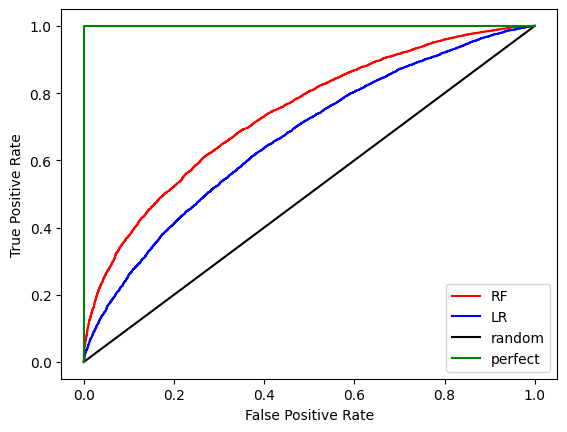

In [28]:
plt.plot(fpr_RF, tpr_RF, "r-", label="RF")
plt.plot(fpr_LR, tpr_LR, "b-", label="LR")
plt.plot([0, 1], [0, 1], "k-", label="random")
plt.plot([0, 0, 1, 1], [0, 1, 1, 1], "g-", label="perfect")
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

There are a few key observations we can make from this figure:

* A model that **randomly guesses** the class labels will produce the **diagonal black line**. To perform better than random guessing, we want the ROC curve to lie **above this line**.

* In general, a model with an ROC curve that stays **farther above the diagonal** has better class separation performance. In this example, the **RF model (red)** appears to perform better than the **LR model (blue)**.

* Although not directly visible from the plot, each point on the ROC curve corresponds to a different classification threshold:

  * a **low threshold** moves the operating point toward the **top right**
  * a **high threshold** moves the operating point toward the **bottom left**

This means that decreasing the threshold generally increases the **True Positive Rate (TPR)**, but often at the cost of increasing the **False Positive Rate (FPR)**.


To evaluate and compare model performance across all classification thresholds, we will use the **Area Under the ROC Curve (AUC)** metric.


In [29]:
auc_RF = roc_auc_score(df.actual_label.values, df.model_RF.values)
auc_LR = roc_auc_score(df.actual_label.values, df.model_LR.values)

print(f"AUC RF:{auc_RF:.3f}")
print(f"AUC LR:{auc_LR:.3f}")

AUC RF:0.738
AUC LR:0.666


As you can see, the area under the curve for the RF model is better than the LR. 

When I plot the ROC curve, I like to add the AUC to the legend as shown below. 

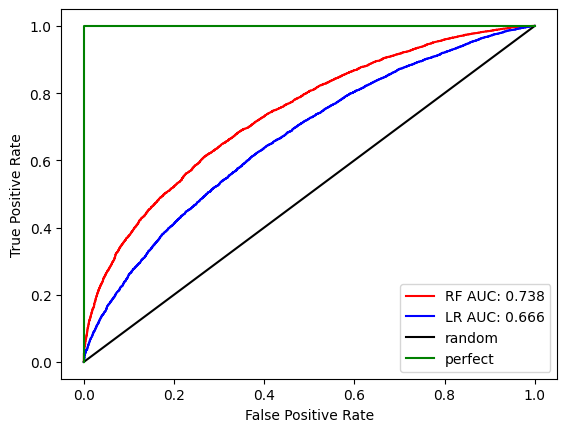

In [30]:
plt.plot(fpr_RF, tpr_RF, "r-", label=f"RF AUC: {auc_RF:.3f}")
plt.plot(fpr_LR, tpr_LR, "b-", label=f"LR AUC: {auc_LR:.3f}")
plt.plot([0, 1], [0, 1], "k-", label="random")
plt.plot([0, 0, 1, 1], [0, 1, 1, 1], "g-", label="perfect")
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

Overall, in this example, the **RF model** achieves the best performance across all evaluated classification metrics.


# Conclusion
In predictive analytics, selecting the best model requires choosing an appropriate evaluation metric.

As you have seen throughout this notebook, there are many metrics available, such as **accuracy, recall, precision, F1-score, and AUC**, and each highlights different aspects of model performance.

There is no universally “best” metric. Instead, the most appropriate metric depends on the business problem, the classification threshold, and the relative cost of different types of prediction errors.

One commonly used metric is **AUC (Area Under the ROC Curve)** because it evaluates model performance across multiple classification thresholds and summarizes the trade-off between the True Positive Rate (TPR) and False Positive Rate (FPR).

Ultimately, choosing the right metric means choosing the one that best aligns with the goals and constraints of the problem you are trying to solve.